In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Original image shape: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

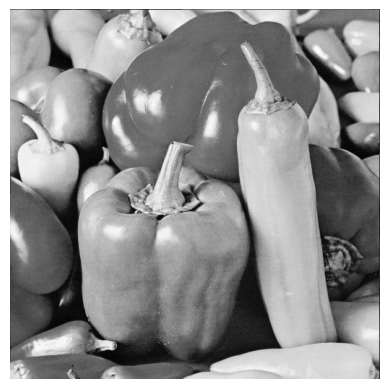

In [ ]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import os
from scipy.fftpack import dct, idct

DEFAULT_WAVELET = 'db4'

def rgb_to_ycbcr(img_rgb):
    return cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2YCrCb).astype(np.float64)


def ycbcr_to_rgb(img_ycbcr):
    img_ycbcr_clipped = np.clip(img_ycbcr, 0, 255)
    return cv2.cvtColor(img_ycbcr_clipped.astype(np.uint8), cv2.COLOR_YCrCb2RGB)


def calculate_snr(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu)
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr


def calculate_mse(actu, pred):
     return np.square(actu - pred).mean()

# --- DWT Implementation ---

def dwt_compress_reconstruct(img_ycbcr, wavelet, level, keep_percentage):
    h, w = img_ycbcr.shape
    reconstructed_img = np.zeros_like(img_ycbcr, dtype=np.float64)
    reduction_factor = keep_percentage / 100.0

    # Decompose
    coeffs_structure = pywt.wavedec2(img_ycbcr[:, :], wavelet, level=level)
    coeffs_thresholded = [None] * len(coeffs_structure) # Initialize list for thresholded coeffs

    # Keep approximation coefficients (LL)
    coeffs_thresholded[0] = coeffs_structure[0]

    # Threshold each detail component (LH, HL, HH) at each level individually
    for i in range(1, len(coeffs_structure)): # Iterate through levels (starting from details)
        thresholded_details_for_level = []
        # coeffs_structure[i] is a tuple (LH, HL, HH)
        for detail_array in coeffs_structure[i]:
            if detail_array.size == 0: # Handle potential empty arrays
                thresholded_details_for_level.append(detail_array)
                continue

            abs_coeffs = np.abs(detail_array.flatten())
            coeffs_to_keep = int(round(abs_coeffs.size * reduction_factor))

            thresholded_array = np.copy(detail_array) # Work on a copy

            if 0 < coeffs_to_keep < abs_coeffs.size:
                # Sort absolute values of *this detail component* in descending order
                sorted_abs_coeffs = np.sort(abs_coeffs)[::-1]
                # Find the threshold value (the k-th largest absolute coefficient)
                threshold = sorted_abs_coeffs[coeffs_to_keep - 1] # -1 because index is 0-based
                # Apply threshold to this specific detail component
                thresholded_array[np.abs(detail_array) < threshold] = 0
            elif coeffs_to_keep == 0:
                # Set all coefficients to zero if keeping 0%
                thresholded_array[:] = 0
            # If coeffs_to_keep >= abs_coeffs.size, keep all coefficients (no thresholding)

            thresholded_details_for_level.append(thresholded_array)

        # Store the tuple of thresholded details for this level
        coeffs_thresholded[i] = tuple(thresholded_details_for_level)

    # Reconstruct
    reconstructed_channel = pywt.waverec2(coeffs_thresholded, wavelet)
    # Ensure reconstructed size matches original
    rh, rw = reconstructed_channel.shape
    reconstructed_img[:min(rh, h), :min(rw, w)] = reconstructed_channel[:min(rh, h), :min(rw, w)]

    return reconstructed_img

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'
# load image
import scipy.io as sio
original_img_gray = sio.loadmat(work_path + 'Data/peppers.mat')['peppers']
print(f"Original image shape: {original_img_gray.shape}")

# plot image
import matplotlib.pyplot as plt
plt.imshow(original_img_gray, cmap='gray')
plt.axis('off')


DWT Processing


  Reduction: 95.0% (Keep: 5.0%)
    SNR: 20.72 dB
    MSE: 24.67


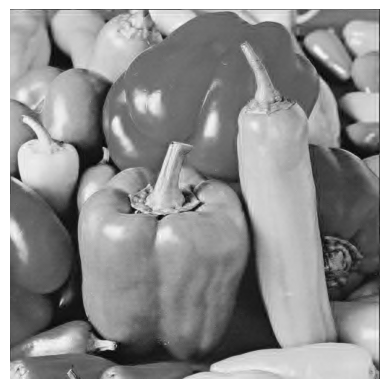

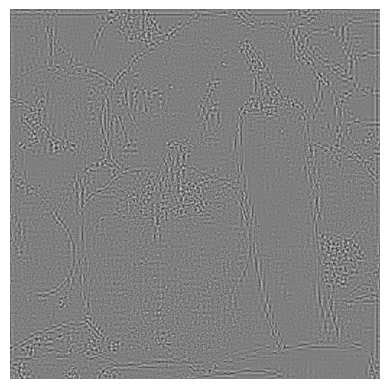

In [ ]:
level = 2
p_reduce = 95

p_keep = 100.0 - p_reduce
print(f"  Reduction: {p_reduce:.1f}% (Keep: {p_keep:.1f}%)")

rec_gray = dwt_compress_reconstruct(original_img_gray.copy(), DEFAULT_WAVELET, level, p_keep)

plt.figure()
plt.imshow(rec_gray, cmap='gray')
plt.axis('off')

err_gray = original_img_gray - rec_gray
plt.figure()
plt.imshow(err_gray, cmap='gray')
plt.axis('off')



snr = calculate_snr(original_img_gray, rec_gray)
print(f"    SNR: {snr:.2f} dB")
mse = calculate_mse(original_img_gray, rec_gray)
print(f"    MSE: {mse:.2f}")